In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\varsh\Downloads\Unified mentor project\European_Bank data.csv")
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df = df.drop(["Surname", "CustomerId"], axis=1)

In [10]:
df.isnull().sum()

Year               0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [11]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age <= 45:
        return "Mid Age"
    elif age <= 60:
        return "Mature"
    else:
        return "Senior"

df["AgeGroup"] = df["Age"].apply(age_group)

In [12]:
def credit_group(score):
    if score < 500:
        return "Low"
    elif score <= 700:
        return "Medium"
    else:
        return "High"

df["CreditGroup"] = df["CreditScore"].apply(credit_group)

In [13]:
def balance_group(b):
    if b == 0:
        return "Zero Balance"
    elif b <= 100000:
        return "Low Balance"
    else:
        return "High Balance"

df["BalanceGroup"] = df["Balance"].apply(balance_group)

In [14]:
df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditGroup,BalanceGroup
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Mid Age,Medium,Zero Balance
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Mid Age,Medium,Low Balance
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Mid Age,Medium,High Balance
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Mid Age,Medium,Zero Balance
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Mid Age,High,High Balance


In [15]:
df["Exited"].mean()

np.float64(0.2037)

In [16]:
df.groupby("Geography")["Exited"].mean()

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

In [17]:
df.groupby("Gender")["Exited"].mean()

Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64

In [18]:
df.groupby("AgeGroup")["Exited"].mean()

AgeGroup
Mature     0.511233
Mid Age    0.153009
Senior     0.247845
Young      0.075564
Name: Exited, dtype: float64

In [19]:
df.groupby("BalanceGroup")["Exited"].mean()

BalanceGroup
High Balance    0.252344
Low Balance     0.205808
Zero Balance    0.138236
Name: Exited, dtype: float64

In [20]:
df.groupby("IsActiveMember")["Exited"].mean()

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

In [21]:
df.groupby("Tenure")["Exited"].mean()

Tenure
0     0.230024
1     0.224155
2     0.191794
3     0.211100
4     0.205258
5     0.206522
6     0.202689
7     0.172179
8     0.192195
9     0.216463
10    0.206122
Name: Exited, dtype: float64

In [22]:
high_value = df[df["Balance"] > 100000]
high_value["Exited"].mean()

np.float64(0.25234423838299647)

C:\Users\varsh\AppData\Local\Temp\ipykernel_16896\2325731252.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Geography", y="Exited", data=df, palette="Set2")


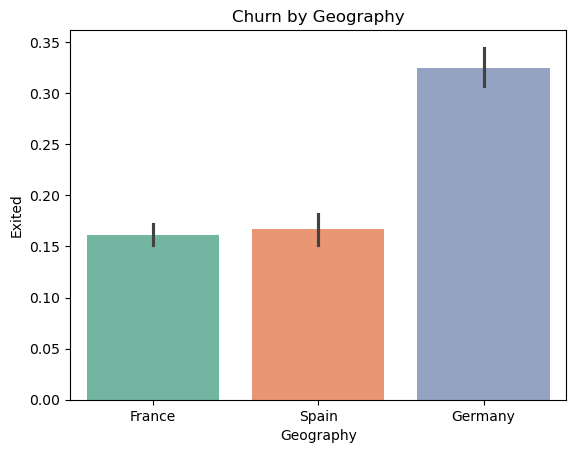

In [28]:
sns.barplot(x="Geography", y="Exited", data=df, palette="Set2")
plt.title("Churn by Geography")
plt.show()

C:\Users\varsh\AppData\Local\Temp\ipykernel_16896\2529092430.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AgeGroup", y="Exited", data=df, palette="coolwarm")


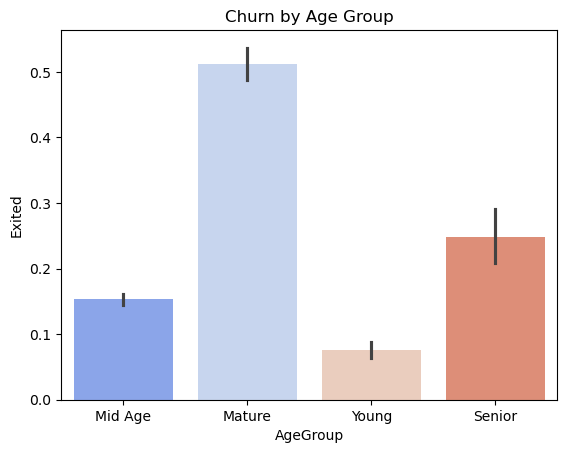

In [33]:
sns.barplot(x="AgeGroup", y="Exited", data=df, palette="coolwarm")
plt.title("Churn by Age Group")
plt.show()

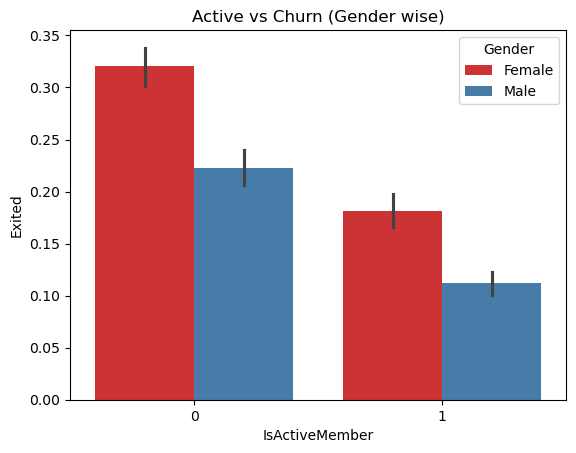

In [35]:
sns.barplot(x="IsActiveMember", y="Exited", data=df, hue="Gender", palette="Set1")
plt.title("Active vs Churn (Gender wise)")
plt.show()